In [3]:
#SYSTEM IMPORTS
import os, re, json, shutil, filecmp, random, itertools, warnings, pickle
from datetime import datetime
from itertools import combinations 
#DS IMPORTS
import numpy as np
import pandas as pd
#PLOTTING IMPORTS
import matplotlib.pyplot as plt
from matplotlib import cm
import seaborn as sns
try:
    plt.style.use('tableau-colorblind10')
except OSError:
    pass
sns.set_palette('colorblind')
#PERSONAL IMPORTS
from preprocessor import DataPreprocessor
from g16parser import g16parser
from plots import plots_class
from prepper import prepper

verbose=False

In [4]:
parse=False
if parse:
    g16parser = g16parser()#log_dir="/Users/jejo/Desktop/Work/heme/logfiles/", 
                        #json_dir="/Users/jejo/Desktop/Work/heme/jsons/", 
                        #csv_path="/Users/jejo/Desktop/Work/heme/tables/pyDISH.csv")
    g16parser.parse()

make_DB=False
if make_DB:
    processor = JSONProcessor()#json_dir="/Users/jejo/Desktop/Work/heme/jsons/", 
                            #output_csv="/Users/jejo/Desktop/Work/heme/DB_test_mac.csv")
    processor.process_files()

In [5]:
df = pd.read_csv("tables/DB.csv")

In [6]:
functions = df["function"].unique()
if verbose: print(functions)
if verbose:
    for column in df.columns:
        print(column)
if verbose: print(df["file_name"])
if verbose: print(df["charge"])
if verbose: print(df["lumo[0]"])
if verbose: print(replacements)

In [7]:
preprocess_data = True
if preprocess_data:
    preprocessor = DataPreprocessor(df=df, keep_homo_lumo=True)
    df, subsets_dict, replacements = preprocessor.process()

Filtered out 5 structures with suspicious iron-axial distances
Suspicious PDB IDs: ['1ac8', '1iyn', '2vnx', '4oq7']
Remaining structures: 1076
Processing comprehensive quantum chemistry data...
Created Fe coordination analysis table: 2890 entries
Created orbital analysis table: 2890 entries
Created charge transfer analysis table: 1800 entries
Created spin contamination analysis table: 2890 entries
Created specialized quantum chemistry analysis tables in: prior_analysis/qm_analysis_tables
Creating filtering system for allowed PDB-ID/charge/multiplicity combinations...
Excluded 0 samples with invalid combinations or poor quality
Filtering report saved to: prior_analysis/filtering_report.json
Excluded 53 samples identified as quantum chemistry outliers
Excluded PDB IDs: ['1ash', '1f65', '1m20', '1n4g', '1xbn', '2spn', '2veb', '2vyw', '2vyz', '2wtg', '2xkh', '2z6s', '4g8w', '5eys', '5f0b', '5o18']
Excluding 295 samples with negative ligand field splitting energy
Removed 295 samples with ne

Testing fixed axial decoding...


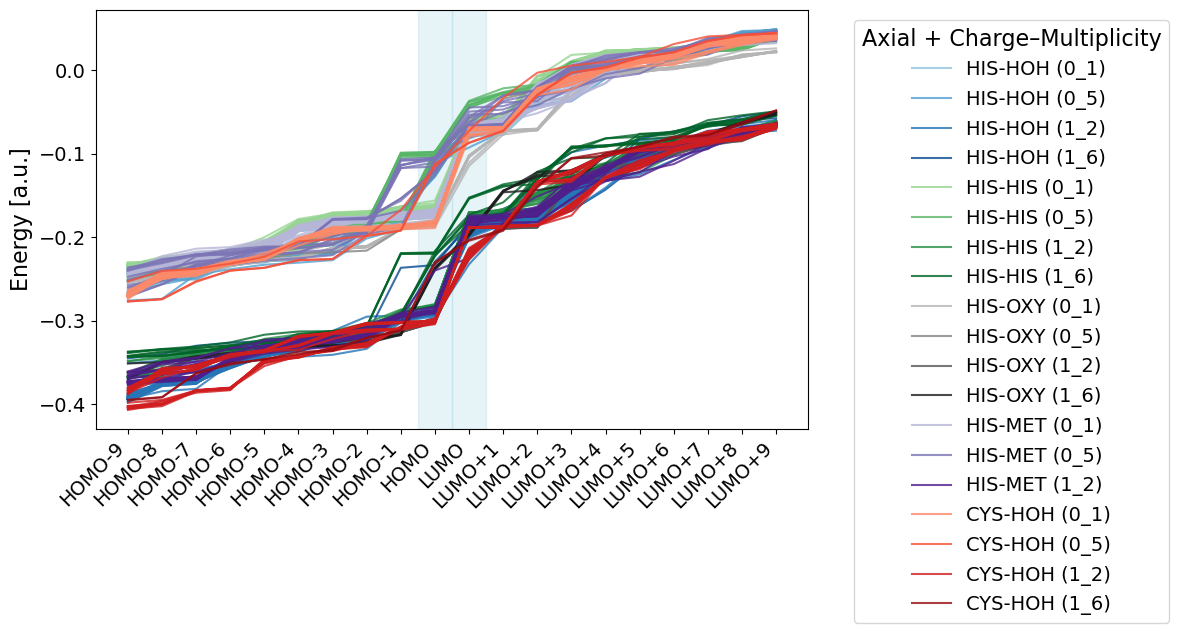

In [8]:
plot_plots=True
if plot_plots:
    # Import a fresh instance to get the fixed decoding
    from plots import plots_class
    mplots = plots_class()
    
    # Reset the decoded flag to ensure decoding happens
    df_copy = df.copy()
    df_copy.attrs["decoded"] = False
    
    print("Testing fixed axial decoding...")
    mplots.plot_x_random(df=df_copy, split=False, axial_color=True, mult_color=True, decode_dicts=replacements)

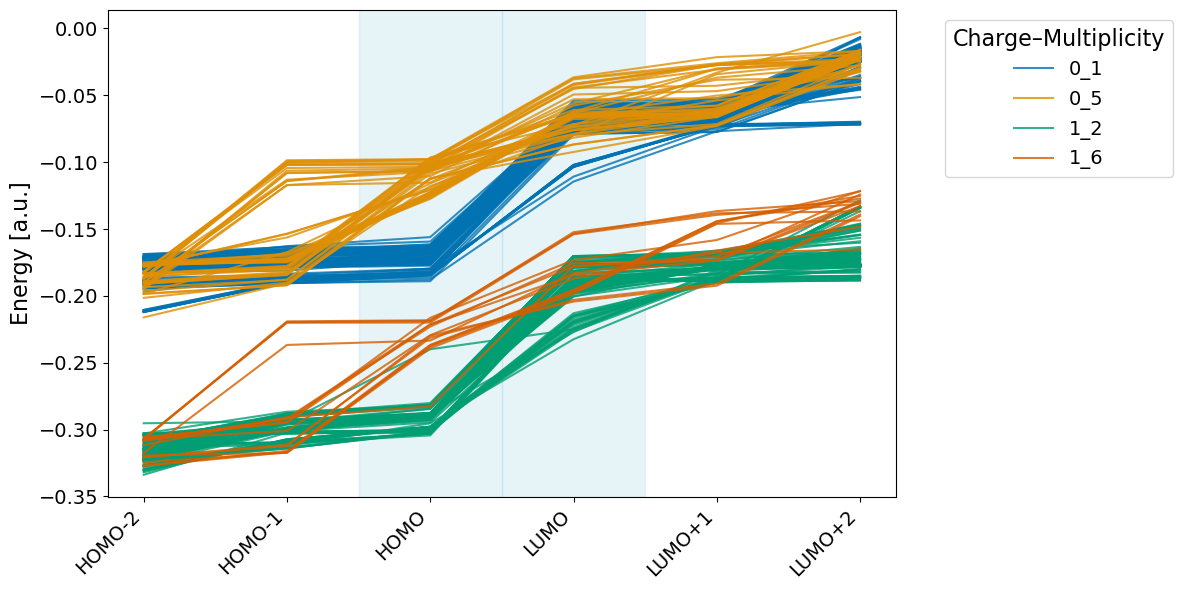

In [9]:
# Plot HOMO/LUMO with charge-multiplicity colors (0-1, 0-5, 1-2, 1-6)
# Limit to HOMO-2 through LUMO+2
from plots import plots_class
import seaborn as sns

mplots = plots_class()
df_cm = df.copy()
df_cm = df_cm[((df_cm['charge'] == 0) & (df_cm['multiplicity'].isin([1, 5]))) |
              ((df_cm['charge'] == 1) & (df_cm['multiplicity'].isin([2, 6])))]

group_order = ['0_1', '0_5', '1_2', '1_6']
palette = sns.color_palette('colorblind', n_colors=len(group_order))
sns.set_palette(palette)

# Order rows so seaborn assigns colors in the intended group order
df_cm['charge_multiplicity'] = df_cm['charge'].astype(str) + '_' + df_cm['multiplicity'].astype(str)
order_map = {g: i for i, g in enumerate(group_order)}
df_cm = df_cm.sort_values(by='charge_multiplicity', key=lambda s: s.map(order_map)).reset_index(drop=True)

# Select only HOMO-2 .. LUMO+2 columns, supporting either naming scheme
subset_cols = []
if 'HOMO' in df_cm.columns:
    subset_cols += ['HOMO-2', 'HOMO-1', 'HOMO', 'LUMO', 'LUMO+1', 'LUMO+2']
else:
    subset_cols += ['homo[7]', 'homo[8]', 'homo[9]', 'lumo[0]', 'lumo[1]', 'lumo[2]']
existing_cols = [c for c in subset_cols if c in df_cm.columns]
df_cm = df_cm[existing_cols + ['charge', 'multiplicity']].copy()

mplots.plot_x_random(df=df_cm, split=False, charge_color=True)
